# Feature Engineering

In this notebook new features will be created to better describe the songs, covering lyrical complexity, sonic characteristics, and contextual metadata. 

A correlation analysis will be performed to cut down columns with too similar values based on the pearson correlation matrix. The result of the new dataset can be found in the engineered_dataset.cv

In [1]:
import pandas as pd
import numpy as np
import altair as alt
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from os import path


alt.data_transformers.enable("vegafusion")

dataset_path = path.join('..', 'dataset', 'cleaned_tracks.csv')
df = pd.read_csv(dataset_path, sep=',')

def analyze_distribution(df, col, title, color_histo, bins=40):
    
    chart_data = df[[col, 'title', 'name_artist']].dropna().copy()
    chart_data[col] = pd.to_numeric(chart_data[col], errors='coerce')
    
    hist = alt.Chart(chart_data).mark_bar(opacity=0.7, color=color_histo).encode(
        x=alt.X(col, bin=alt.Bin(maxbins=bins), title=title),
        y=alt.Y('count()', title='Count'),
        tooltip=[alt.Tooltip(col, bin=True), 'count()']
    ).properties(title=f'Distribution of Tracks by {title}', width=800, height=300)
    
    box = alt.Chart(chart_data).mark_boxplot().encode(
        x=alt.X(col, title=title),
        tooltip=[alt.Tooltip(f'min({col})'), alt.Tooltip(f'max({col})')]
    ).properties(width=800, height=100)
    
    display(hist & box)

    print(f"Top 10 Highest {title}:")
    display(chart_data.sort_values(by=col, ascending=False).head(10))
    
    print(f"Bottom 10 Lowest {title}:")
    display(chart_data.sort_values(by=col, ascending=True).head(10))

## Lyrical Features

### words_per_minute

The number of tokens (words) divided by the track duration in minutes.
Rap styles vary significantly by speed his feature distinguishes technical/fast flow rap from mumble Rap or melodic trap, which tends to be slower and more spaced out.

In [2]:
df['words_per_minute'] = df['n_tokens'] / (df['duration_ms'] / 60000)

analyze_distribution(df, 'words_per_minute', 'words_per_minute', 'green')

alt.VConcatChart(...)

Top 10 Highest words_per_minute:


,words_per_minute,title,name_artist
8306,1018.813666,Madtadone 2011,MadMan
5530,945.327146,Nostalgia Istantanea (Under-21 MashUp),Dargen D’Amico
8296,900.366375,Madtadone 2013,MadMan
8271,854.819277,Madtadone 2018,MadMan
8302,811.445783,Madtadone 2012,MadMan
2674,763.600302,Effe,Inoki
8312,707.386824,Raid,MadMan
8281,699.293251,Madtadone 2016,MadMan
9746,695.162482,Come al Solito,Salmo
480,613.572102,Stai Giù,Lazza


Bottom 10 Lowest words_per_minute:


,words_per_minute,title,name_artist
5341,0.0,Nelle Mie Mani,Baby K
7447,0.0,Beef,DrefGold
6638,0.0,Ombre Cinesi (Strumentale),Don Joe
7433,0.0,Nasty Freestyle,DrefGold
5048,0.0,Don't Duck With Me,Il Tre
9783,0.0,Intro,Salmo
5739,0.0,Answers Within - Focus Version,Shade
9768,0.0,Introliberassociazione,Salmo
9742,0.0,BLOCCO 181 - Title Track,Salmo
9744,0.0,DJ Valium,Salmo


### syllables_per_beat

The number of tokens (words) processed relative to the musical beat (BPM) rather than just time. Unlike Words Per Minute, this measures how "full" the flow is relative to the base of the song.

In [3]:
df['syllables_per_beat'] = df['n_tokens'] / ((df['duration_ms'] / 60000) * df['bpm'])

analyze_distribution(df, 'syllables_per_beat', 'syllables_per_beat', 'darkred')

alt.VConcatChart(...)

Top 10 Highest syllables_per_beat:


,syllables_per_beat,title,name_artist
8306,11.837036,Madtadone 2011,MadMan
5530,9.470318,Nostalgia Istantanea (Under-21 MashUp),Dargen D’Amico
8281,8.124704,Madtadone 2016,MadMan
8312,7.819885,Raid,MadMan
2674,7.636003,Effe,Inoki
8271,7.445512,Madtadone 2018,MadMan
9746,6.958583,Come al Solito,Salmo
8296,6.419725,Madtadone 2013,MadMan
2400,5.871031,One Take FM Free Mic,Rocco Hunt
8302,5.785710,Madtadone 2012,MadMan


Bottom 10 Lowest syllables_per_beat:


,syllables_per_beat,title,name_artist
3629,0.0,Tentazioni,Neffa
68,0.0,Luciano Pavarotty // Glock,Rosa Chemical
58,0.0,LATTE +,Rosa Chemical
65,0.0,C. A. S.,Rosa Chemical
3602,0.0,Arrivi e partenze,Neffa
9436,0.0,Fannullone,Samuel Costa
3583,0.0,Il Funk Dopo La Morte,Neffa
61,0.0,Punk 'a Piana,Rosa Chemical
497,0.0,Come Me,Lazza
2215,0.0,2031 (Intro),Fabri Fibra


### explicitness_density

The ratio of total swear words (Italian + English) to the total number of tokens. Captures the "explicitness" of the content.

In [4]:
df['explicitness_density'] = (df['swear_IT'].fillna(0) + df['swear_EN'].fillna(0)) / df['n_tokens']
df['explicitness_density'] = df['explicitness_density'].fillna(0)  #handle div by zero

analyze_distribution(df, 'syllables_per_beat', 'syllables_per_beat', 'darkblue')

alt.VConcatChart(...)

Top 10 Highest syllables_per_beat:


,syllables_per_beat,title,name_artist
8306,11.837036,Madtadone 2011,MadMan
5530,9.470318,Nostalgia Istantanea (Under-21 MashUp),Dargen D’Amico
8281,8.124704,Madtadone 2016,MadMan
8312,7.819885,Raid,MadMan
2674,7.636003,Effe,Inoki
8271,7.445512,Madtadone 2018,MadMan
9746,6.958583,Come al Solito,Salmo
8296,6.419725,Madtadone 2013,MadMan
2400,5.871031,One Take FM Free Mic,Rocco Hunt
8302,5.785710,Madtadone 2012,MadMan


Bottom 10 Lowest syllables_per_beat:


,syllables_per_beat,title,name_artist
3629,0.0,Tentazioni,Neffa
68,0.0,Luciano Pavarotty // Glock,Rosa Chemical
58,0.0,LATTE +,Rosa Chemical
65,0.0,C. A. S.,Rosa Chemical
3602,0.0,Arrivi e partenze,Neffa
9436,0.0,Fannullone,Samuel Costa
3583,0.0,Il Funk Dopo La Morte,Neffa
61,0.0,Punk 'a Piana,Rosa Chemical
497,0.0,Come Me,Lazza
2215,0.0,2031 (Intro),Fabri Fibra


### lyrical_complexity

A composite metric combining vocabulary richness (lexical_density) with the sophistication of the words used (char_per_tok). Differentiates more "original" rap (high density, longer words) from repetitive trap (low density, shorter words).

In [5]:
df['lyrical_complexity'] = df['lexical_density'] * df['char_per_tok']

analyze_distribution(df, 'lyrical_complexity', 'lyrical_complexity', 'darkorange')

alt.VConcatChart(...)

Top 10 Highest lyrical_complexity:


,lyrical_complexity,title,name_artist
2409,5.222432,M.I.S.T.A.M.A.N.,Mistaman
3713,5.187500,Outcipit,Frankie hi-nrg mc
2670,5.000000,Nobiltà Di Strada (Intro),Inoki
8848,5.000000,Non esistono risposte intelligenti,Highsnob
10524,4.857143,Intro (Solo Un Uomo),Mondo Marcio
5654,4.857143,Classifiche*,Geolier
3995,4.750000,Mors mea tacci tua,Caparezza
8484,4.744318,My Funny Valentine,Achille Lauro
4354,4.736842,Dovete Andarvene,Bassi Maestro
4943,4.717742,Intro (Get Maad),Vacca


Bottom 10 Lowest lyrical_complexity:


,lyrical_complexity,title,name_artist
68,0.0,Luciano Pavarotty // Glock,Rosa Chemical
65,0.0,C. A. S.,Rosa Chemical
61,0.0,Punk 'a Piana,Rosa Chemical
58,0.0,LATTE +,Rosa Chemical
7433,0.0,Nasty Freestyle,DrefGold
10676,0.0,Primo interludio,Mondo Marcio
5048,0.0,Don't Duck With Me,Il Tre
10683,0.0,Secondo interludio,Mondo Marcio
5141,0.0,INTERMEZZO,M¥SS KETA
8774,0.0,Minimal Rome,Cor Veleno


## Audio Features

### audio_aggressiveness

A composite score of audio features capturing intensity, timbre, percussiveness, and speed (Loudness, Rolloff, Spectral Flux, and BPM). This metric distinguishes high-energy, aggressive tracks (e.g. drill, hardcore) from more laid-back productions (lo-fi).

In [6]:
#scaler for composite features (requires normalization (Min-Max) of components first because they have different scales)
scaler = MinMaxScaler()
audio_feats_agg = ['rolloff', 'loudness', 'flux', 'bpm']

agg_data = df[audio_feats_agg].copy()
norm_agg = (agg_data - agg_data.min()) / (agg_data.max() - agg_data.min())
df['audio_aggressiveness'] = norm_agg.mean(axis=1, skipna=False)

analyze_distribution(df, 'audio_aggressiveness', 'audio_aggressiveness', 'purple')

alt.VConcatChart(...)

Top 10 Highest audio_aggressiveness:


,audio_aggressiveness,title,name_artist
7913,0.582178,No Problema RMX,Jack The Smoker
260,0.573865,Particolare,thasup
615,0.571416,Il Nome,Nerone
9987,0.570313,Milano Ovest,Shiva
4780,0.563790,Grazie A Nessuno,Vacca
10070,0.563634,Civico 30 freestyle,Shiva
177,0.561343,Alfa (Intro),Alfa
337,0.560896,2 TIRI,Lazza
5056,0.560411,Freestyle,Il Tre
5018,0.560411,One Take FM Free Mic [2023],Il Tre


Bottom 10 Lowest audio_aggressiveness:


,audio_aggressiveness,title,name_artist
3158,0.068938,Squali*,Sfera Ebbasta
645,0.187504,2P solo,Nerone
8506,0.190845,FM 94.95 - Re della Misère,Achille Lauro
10650,0.192445,Brutto Carattere,Mondo Marcio
8484,0.193543,My Funny Valentine,Achille Lauro
3222,0.193555,Rose Viola Pt. 2,Ghemon
3247,0.194745,SINDROME DI STOCCOLMA,Ghemon
8514,0.195556,PREQUEL,Achille Lauro
472,0.195674,Vince Carter Freestyle,Lazza
8828,0.196541,Rooftop,Highsnob


### harmonic_complexity

An indicator of how rich the instrumental is, combining spectral_complexity (number of peaks) and flatness (inverse of noisiness).
High complexity and low flatness usually indicate a rich melody with many instruments. Low complexity and high flatness suggest a minimalist, perhaps noisy or drum-focused beat.

In [7]:
df['harmonic_complexity'] = df['spectral_complexity'] * (1 - df['flatness'])

analyze_distribution(df, 'harmonic_complexity', 'harmonic_complexity', 'hotpink')

alt.VConcatChart(...)

Top 10 Highest harmonic_complexity:


,harmonic_complexity,title,name_artist
8817,38.018594,No Boyfriend,Highsnob
8149,36.473134,Dai dai dai,Shablo
7351,36.065881,Haterproof (Detto Fatto RMX),Gemitaiz
10262,35.707818,Gotham City,Caneda
9830,35.483322,Most Wanted Pt.2,Tormento
5980,34.845859,Dramma Music,Emis Killa
10330,34.472143,Il selvaggio,Caneda
5500,33.985642,A meno di te,Dargen D’Amico
4862,33.672830,Miliardo,Vacca
9781,33.619126,Vuoto (2007),Salmo


Bottom 10 Lowest harmonic_complexity:


,harmonic_complexity,title,name_artist
4877,0.000000,In Tv,Vacca
8311,0.000000,Madtadone 2015,MadMan
3158,0.018680,Squali*,Sfera Ebbasta
8155,0.060539,Timeless Spirit,Shablo
3040,0.180415,Lemon Pepper Freestyle,Rondodasosa
6655,0.209624,Maxidelitto di Scarsi (Bonus Track),Nesli
9156,0.211406,Cinque a uno,Colle Der Fomento
3662,0.211511,Ebby & Nike Pt.2,Neffa
7652,0.221056,Alla mia maniera*,Tony Boy
3562,0.225354,El Chico Loco,Neffa


### vocal_clarity

An estimation of how "clear" or "bright" the vocal mix is, using rolloff relative to loudness. Modern productions often have very high rolloff (crisp vocals) and high loudness. Lo-fi or "lower" productions might have lower rolloff despite high loudness.

In [8]:
df['vocal_clarity'] = df['rolloff'] / df['loudness'].abs().clip(lower=1)

analyze_distribution(df, 'vocal_clarity', 'vocal_clarity', 'yellowgreen')

alt.VConcatChart(...)

Top 10 Highest vocal_clarity:


,vocal_clarity,title,name_artist
254,3210.059556,COVID-19 Freestyle,thasup
3682,2553.580700,Chiedi Chiedi,Frankie hi-nrg mc
10962,2452.371800,Pensavo fosse amore e invece... (Roofio RMX),Fedez
10961,2297.091300,Faccio Brutto (2nd Roof RMX),Fedez
10648,2147.649200,Freestyle,Mondo Marcio
8828,2058.583700,Rooftop,Highsnob
8810,1887.357159,Balaclava,Highsnob
8155,1762.399100,Timeless Spirit,Shablo
4032,1742.143595,Eroe (storia di Luigi Delle Bicocche) [Radio E...,Caparezza
7350,1694.704516,Noi Siamo Così RMX,Gemitaiz


Bottom 10 Lowest vocal_clarity:


,vocal_clarity,title,name_artist
7544,2.149662,Fino a domani,Tony Boy
7572,3.234930,Si si,Tony Boy
10140,5.933217,Back In Blood RMX,Shiva
7530,6.980528,Correre,Tony Boy
261,7.179384,Veri Fra*,thasup
5141,7.204503,INTERMEZZO,M¥SS KETA
6829,7.652345,GUARDA COME FL3XO,MamboLosco
9362,8.287103,esse Type Beat,Papa V
2775,8.476395,187,Doll Kill
7557,8.552977,Etc,Tony Boy


## Metadata Features

### collab_count

The number of featured artists on a track.

In [9]:
def count_featured(val):
    if pd.isna(val):
        return 0
    return len(str(val).split(','))

df['collab_count'] = df['featured_artists'].apply(count_featured)

### artist_rel_popularity

The popularity of a song normalized by the artist's average popularity.

In [10]:
df['artist_mean_pop'] = df.groupby('name_artist')['popularity'].transform('mean')
df['artist_std_pop'] = df.groupby('name_artist')['popularity'].transform('std')

df['artist_rel_popularity'] = (df['popularity'] - df['artist_mean_pop']) / df['artist_std_pop']
df['artist_rel_popularity'] = df['artist_rel_popularity'].fillna(0) #handle artists with 1 song

analyze_distribution(df, 'artist_rel_popularity', 'artist_rel_popularity', 'darkturquoise')

alt.VConcatChart(...)

Top 10 Highest artist_rel_popularity:


,artist_rel_popularity,title,name_artist
4796,5.759229,Non Mi Giudicare,Vacca
2461,5.363353,Ghost Track,Mistaman
6672,4.753701,Hey Tu,Nesli
2877,4.636906,Se mai,Johnny Marsiglia
6179,4.516589,In teoria,Willie Peyote
2504,4.454367,Lo Faccio Marcio,Mistaman
668,4.426021,Another Day My Blocco,Nerone
1559,4.378350,Su di me (Outtake),Piotta
2646,4.313632,Io non T.V.B.,Inoki
728,4.298578,First Love,Babaman


Bottom 10 Lowest artist_rel_popularity:


,artist_rel_popularity,title,name_artist
5651,-4.246459,COVID19-FREESTYLE,Geolier
5649,-4.091573,America*,Geolier
9402,-3.737209,Capra,Papa V
6570,-3.685585,Josip Broz,Ernia
784,-3.664644,esse Type Beat,Niky Savage
9362,-3.348082,esse Type Beat,Papa V
7859,-3.326441,From BK to RM,Noyz Narcos
6577,-3.305319,Spoiler 1*,Ernia
7867,-3.154461,Non è un gioco,Noyz Narcos
3791,-3.134742,Bandar-log,Tedua


### season_rel_popularity

The popularity of a track standardized (Z-score) against the average popularity of all tracks released in the same season (Winter, Spring, Summer, Autumn). A song released in summer might need a higher raw popularity score to be considered a standout "hit" compared to a song released in a quieter season.

In [11]:
def get_season(month):
    if pd.isna(month):
        return np.nan
    month = int(month)
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    return np.nan

df['release_season'] = df['month'].apply(get_season)

#Mean and Std Dev of popularity for each season
season_stats = df.groupby('release_season')['popularity'].agg(['mean', 'std']).reset_index()
season_stats.rename(columns={'mean': 'season_mean_pop', 'std': 'season_std_pop'}, inplace=True)

df = df.merge(season_stats, on='release_season', how='left')

#compute Z-score: (Popularity - Season Mean) / Season Std
df['season_rel_popularity'] = (df['popularity'] - df['season_mean_pop']) / df['season_std_pop']

df['season_rel_popularity'] = df['season_rel_popularity'].fillna(0)

print(df[['title', 'release_season', 'popularity', 'season_rel_popularity']].head())

analyze_distribution(df, 'season_rel_popularity', 'season_rel_popularity', 'tan')

         title release_season  popularity  season_rel_popularity
0  polka 2 :-/         Spring        46.0               0.692770
1        POLKA         Spring        46.0               0.692770
2  britney ;-)         Winter        39.0               0.402222
3          CEO         Spring        47.0               0.745324
4       LONDRA         Spring        41.0               0.430000


alt.VConcatChart(...)

Top 10 Highest season_rel_popularity:


,season_rel_popularity,title,name_artist
668,3.387527,Another Day My Blocco,Nerone
10949,3.373021,My Life,Fedez
5996,3.373021,Loco Loco Loco,Bushwaka
7249,3.337498,May Day,Gemitaiz
2988,3.240709,MY LIFE,Rondodasosa
10953,3.215360,I'm So High,Fedez
265,3.201507,Coraline In Love,thasup
2461,3.173558,Ghost Track,Mistaman
8121,3.142830,You get ready,Coez
463,3.093891,Nasty Girl,Lazza


Bottom 10 Lowest season_rel_popularity:


,season_rel_popularity,title,name_artist
1297,-1.799294,For Pecché,Capo Plaza
9316,-1.799294,I LOVE IT,ANNA
4617,-1.799294,Carta E Penna,Mistico
1786,-1.799294,Vai Vai,Clementino
5320,-1.799294,Intro (2021),Baby K
8833,-1.799294,Baby No,Highsnob
8511,-1.799294,FM 96.97 - Ave O Maria,Achille Lauro
10234,-1.799294,Piegature,Caneda
6944,-1.799294,Consegnato.02,Frah Quintale
5755,-1.799294,Бары,Shade


## Distribution Analysis

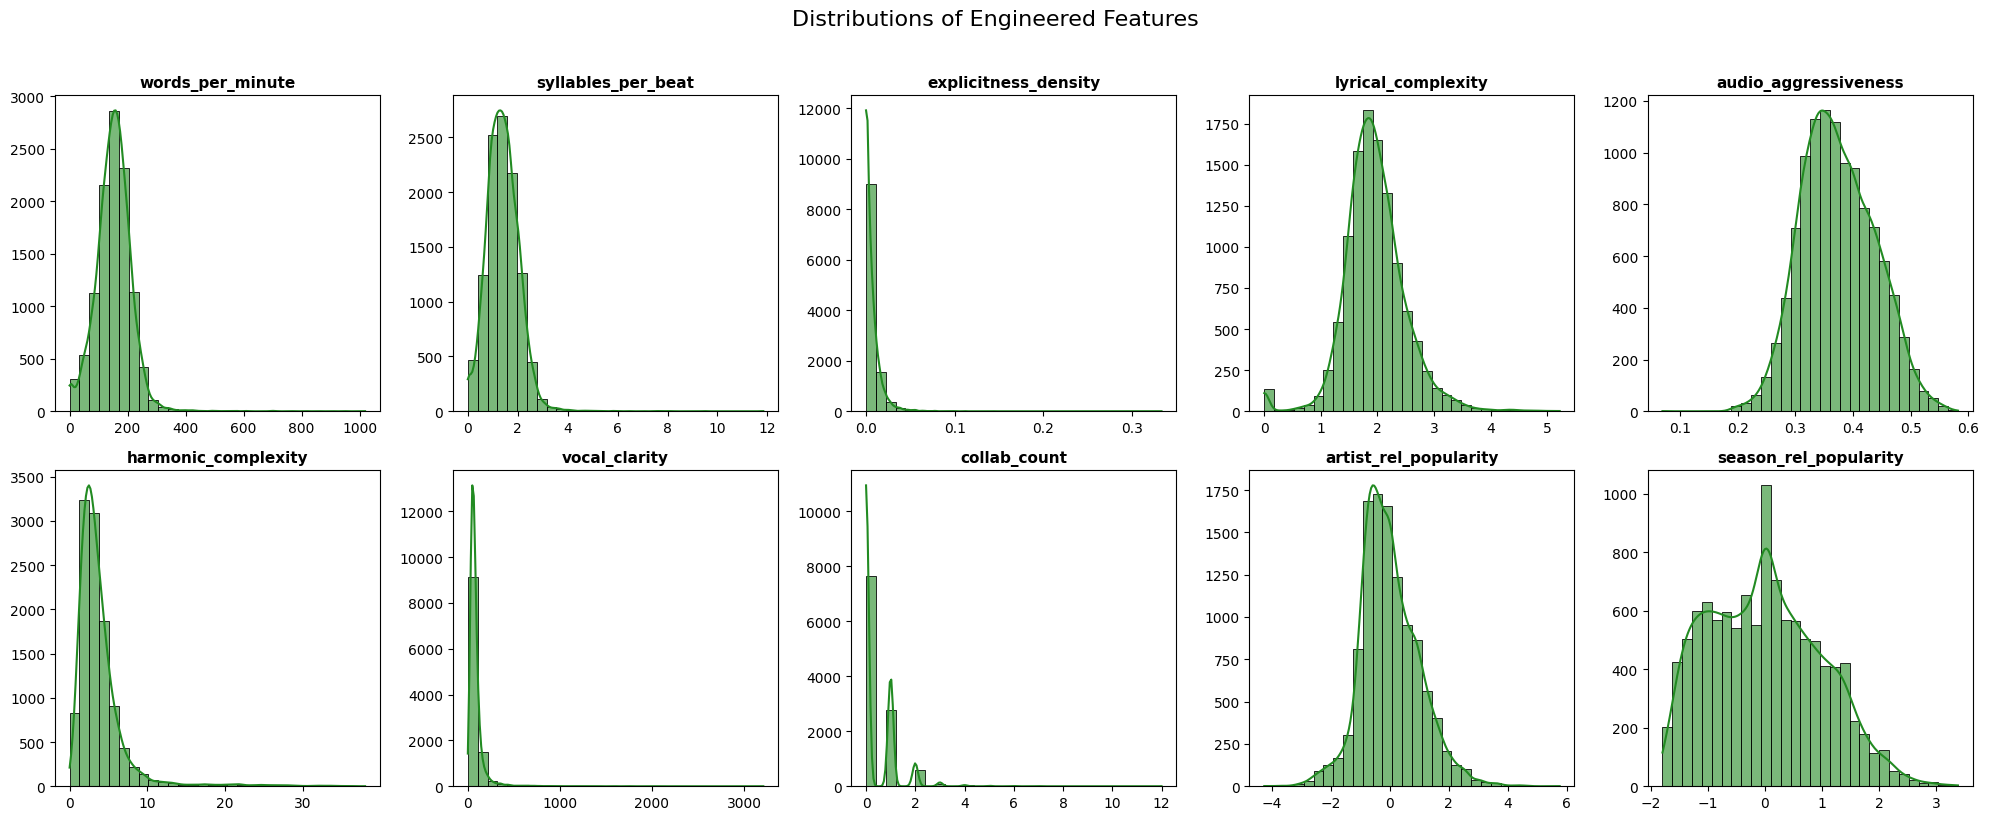

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

new_engineered_cols = [
    'words_per_minute', 
    'syllables_per_beat', 
    'explicitness_density', 
    'lyrical_complexity', 
    'audio_aggressiveness', 
    'harmonic_complexity', 
    'vocal_clarity', 
    'collab_count', 
    'artist_rel_popularity', 
    'season_rel_popularity'
]

#create a 2x5 grid (2 Rows, 5 Columns)
n_cols = 5
n_rows = 2

#adjusted figsize: width=20 (to fit 5 cols), height=8 (to fit 2 rows)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8)) 
axes = axes.flatten()

for i, col in enumerate(new_engineered_cols):
    if col in df.columns:
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='forestgreen', bins=30, alpha=0.6)
        
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].text(0.5, 0.5, f"Column '{col}'\nnot found", 
                     horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)

for j in range(len(new_engineered_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distributions of Engineered Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Feature Correlation Analysis

We analyze the correlation between new features and old numerical columns to assess their potential correlation to old columns.

In [13]:
base_numerical_cols = [
    'popularity', 'stats_pageviews', 'duration_ms',
    'bpm', 'centroid', 'rolloff', 'flux', 'flatness', 'spectral_complexity', 'pitch', 'loudness',
    'n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause',
    'swear_IT', 'swear_EN'
]

new_features = [
    'words_per_minute', 'syllables_per_beat', 'explicitness_density', 
    'lyrical_complexity', 'audio_aggressiveness', 'harmonic_complexity',
    'vocal_clarity', 'collab_count', 'artist_rel_popularity', 'season_rel_popularity'
]

cols_to_use = base_numerical_cols + new_features

exclude_cols = ['zcr', 'rms']
cols_to_use = [col for col in cols_to_use if col not in exclude_cols and col in df.columns]

df_corr = df[cols_to_use].copy()
corr_matrix = df_corr.corr()

corr_long = corr_matrix.stack().reset_index()
corr_long.columns = ['Variable 1', 'Variable 2', 'Correlation']
corr_long['Correlation_Label'] = corr_long['Correlation'].apply(lambda x: f"{x:.2f}")

base = alt.Chart(corr_long).encode(
    x=alt.X('Variable 2', title=None, sort=cols_to_use),
    y=alt.Y('Variable 1', title=None, sort=cols_to_use)
)

heatmap = base.mark_rect().encode(
    color=alt.Color(
        'Correlation',
        scale=alt.Scale(scheme='redblue', domain=[-1, 1]),
        legend=alt.Legend(title="Correlation")
    ),
    tooltip=['Variable 1', 'Variable 2', alt.Tooltip('Correlation', format='.2f')]
)

text = base.mark_text(size=8).encode(
    text='Correlation_Label',
    color=alt.condition(
        alt.expr.abs(alt.datum.Correlation) > 0.5,
        alt.value('white'),
        alt.value('black')
    )
)

chart = (heatmap + text).properties(
    title='Pearson correlation matrix (audio features, lyrics stats, metadata, engineered features)',
    width=950,
    height=950
)

chart.interactive()

alt.LayerChart(...)

The derived features lyrical_complexity and season_rel_popularity will be excluded because they have high correlation with their underlying base features (factor used to derive them), offering no additional information.